# Projeto De Machine Learning - 2026.1

## Notebook 04 — Validação, Experimentos e Análises Complementares

### Projeto Kyra Pesquisa

*Maria Beatriz Ribeiro, Juliane Oliveira e Emanuel Gandra*

## 1. Objetivo

Este notebook tem duas funções:

**1.1 Resumo do pipeline completo** — consolida o que foi feito nos notebooks 01, 02 e 03 para servir
de referência rápida antes da entrega final.

**1.2 Experimentos de validação** — reproduz análises que estavam no notebook experimental
(`kyra-tests.ipynb`) e que ainda não haviam sido portadas para o pipeline oficial:

| Experimento | O que valida |
|---|---|
| Coerência C_v (gensim) | Se os tópicos LDA/NMF fazem sentido semântico |
| Jaccard LDA × NMF | Quais tópicos são robustos (aparecem nos dois modelos) |
| Classificação supervisionada | Se o conteúdo das falas distingue os projetos |
| Chi² por classe | Quais palavras mais identificam cada projeto/público |
| Análise de sentimento | Valência positiva/negativa por projeto e cluster |

**Input:** outputs do notebook 03 (`chunks_with_clusters_topics.parquet`, `nmf_topics.csv`, `lda_topics.csv`)  
**Input:** base principal (`interviews_chunks_modeling.parquet`)  
**Output:** tabelas e gráficos de validação em `outputs/validacao/`

---
## 2. Resumo do Pipeline — Notebooks 01 a 03

### Notebook 01 — Diagnóstico da Base (`01_diagnostico_base_preprocessamento_v3.ipynb`)

**O que faz:** baixa as duas tabelas do BigQuery (`entrevistas_chunks_v2` e `entrevistas_docs_v2`),
cataloga colunas, perfila qualidade, detecta idioma por chunk e audita ruídos residuais.

**Principais descobertas:**
- 12.041 chunks brutos | 155 documentos
- 83% dos chunks tinham ruídos (timestamps, speaker labels, filenames de áudio)
- 99,9% continham a string `created` do cabeçalho de página dos PDFs
- Distribuição de idioma: 8.628 PT | 3.138 misto | 238 ES | 37 EN

**Output:** `data/diagnostics/` com 30+ CSVs de auditoria

---

### Notebook 02 — Pré-processamento (`02_preprocessamento_entrevistas_kyra_corrigido_v3.ipynb`)

**O que faz:** reconstrói os chunks do zero a partir dos documentos completos, com limpeza
profunda e segmentação em janelas de ~250 palavras.

**Pipeline aplicado:**
1. Remove cabeçalho de página: `Meeting Title ... created at ... N / N`
2. Remove speaker labels (`Speaker 1 - 00:08`), URLs e nomes de arquivo
3. Extrai 63.647 turnos/falas individuais
4. Segmenta em chunks (min 120, target 250, max 330 palavras)
5. Filtra somente português para a base principal

**Output:** `data/processed/interviews_chunks_modeling.parquet` — **4.976 chunks em PT** sem ruído residual

---

### Notebook 03 — Clusterização e Tópicos (`03_clusterizacao_topicos_insights_v2.ipynb`)

**O que faz:** gera embeddings, aplica clustering e modelos de tópicos, depois cruza
os resultados com metadados para gerar insights segmentados.

**Pipeline:**
1. Embeddings: TF-IDF + SVD (256 dimensões)
2. KMeans com grid search k=8…30 — selecionado **K=18** (silhouette=0.113, ARI=0.865)
3. NMF: **18 tópicos** (melhor diversidade/estabilidade)
4. LDA: **10 tópicos** (melhor perplexidade)
5. Rótulos automáticos por TF-IDF por cluster
6. Insights com **lift** por projeto, público, marca e tipo de sessão

**Output:** `outputs/clusterizacao_insights_v2/20260520_113457/` com parquet final, tabelas e heatmaps

---

## 3. Setup e Carregamento

In [1]:
# Descomente se precisar instalar gensim:
# !pip install -q gensim

In [2]:
import os
import re
import warnings
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_selection import chi2
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_colwidth', 120)

RANDOM_STATE = 42

# Detecta raiz do projeto independente do CWD do Jupyter
_cwd = Path(os.path.abspath(''))
_root = _cwd
for _ in range(4):
    if (_root / 'data' / 'processed').exists():
        break
    _root = _root.parent

PASTA_DATA    = _root / 'data' / 'processed'
PASTA_OUTPUTS = sorted((_root / 'outputs' / 'clusterizacao_insights_v2').glob('*'))[-1]
PASTA_TABLES  = PASTA_OUTPUTS / 'tables'
PASTA_VAL     = _root / 'outputs' / 'validacao'
PASTA_VAL.mkdir(parents=True, exist_ok=True)

print(f'Raiz do projeto : {_root}')
print(f'Dados           : {PASTA_DATA}')
print(f'Run selecionada : {PASTA_OUTPUTS.name}')
print(f'Outputs validação: {PASTA_VAL}')

Raiz do projeto : /Users/I759133/Library/CloudStorage/OneDrive-SAPSE/Documentos Juliane/IBMEC/SEXTO SEMESTRE/PROJETO/kyrapesquisa/Kyra Atual
Dados           : /Users/I759133/Library/CloudStorage/OneDrive-SAPSE/Documentos Juliane/IBMEC/SEXTO SEMESTRE/PROJETO/kyrapesquisa/Kyra Atual/data/processed
Run selecionada : 20260520_113457
Outputs validação: /Users/I759133/Library/CloudStorage/OneDrive-SAPSE/Documentos Juliane/IBMEC/SEXTO SEMESTRE/PROJETO/kyrapesquisa/Kyra Atual/outputs/validacao


In [3]:
# Carrega base principal
df = pd.read_parquet(PASTA_DATA / 'interviews_chunks_modeling.parquet')

# Desserializa tokens (coluna pode estar como JSON string ou lista)
if 'tokens_topic' in df.columns and isinstance(df['tokens_topic'].iloc[0], str):
    try:
        df['tokens_topic'] = df['tokens_topic'].apply(json.loads)
    except Exception:
        df['tokens_topic'] = df['tokens_topic'].str.split()

# Carrega resultado com clusters e tópicos
df_clusters = pd.read_parquet(PASTA_OUTPUTS / 'chunks_with_clusters_topics.parquet')

# Carrega tópicos NMF e LDA salvos
df_nmf_topics = pd.read_csv(PASTA_TABLES / 'nmf_topics.csv')
df_lda_topics = pd.read_csv(PASTA_TABLES / 'lda_topics.csv')

print(f'Base principal : {df.shape[0]:,} chunks | {df["projeto"].nunique()} projetos')
print(f'Com clusters   : {df_clusters.shape[0]:,} chunks')
print(f'Tópicos NMF    : {len(df_nmf_topics)}')
print(f'Tópicos LDA    : {len(df_lda_topics)}')
df[['chunk_id', 'projeto', 'publico', 'text_for_keywords']].head(3)

Base principal : 4,976 chunks | 12 projetos
Com clusters   : 4,976 chunks
Tópicos NMF    : 18
Tópicos LDA    : 10


,chunk_id,projeto,publico,text_for_keywords
0,doc_b53730e47cc798ef_pp_ch_0001,biome,nao_inferido,minutinho esperar assistem inclusive ana entrarem ligo webinaria conseguem entrar ana esperando entrar soltar videoz...
1,doc_b53730e47cc798ef_pp_ch_0002,biome,nao_inferido,estiver basta deixar seu microfone silencioso enquanto estiver lembre manter sua camera sempre aberta conversa sua c...
2,doc_b53730e47cc798ef_pp_ch_0003,biome,nao_inferido,novo seguinte entrar tema conversar pudesse conhecer melhor conhecem ninguem conhece aparentemente ninguem conhece c...


## 4. Experimento 1 — Coerência C_v (Gensim)

### Por que usar C_v em vez da coerência do notebook 03?

O notebook 03 calculou coerência via **similaridade cosseno entre termos** — uma proxy razoável,
mas que não considera a co-ocorrência real das palavras nos textos.

A métrica **C_v (gensim)** é mais robusta: calcula a probabilidade de co-ocorrência dos
top-N termos de cada tópico numa janela deslizante sobre os textos originais.
Ela correlaciona melhor com julgamento humano sobre "este tópico faz sentido?".

Aqui re-treinamos LDA para K = {6, 8, 10, 12, 15, 18} e comparamos com os scores
do notebook 03 para verificar se o K=10 do LDA e K=18 do NMF são boas escolhas.

In [4]:
try:
    from gensim.corpora import Dictionary
    from gensim.models.coherencemodel import CoherenceModel
    GENSIM_OK = True
    print('gensim disponível.')
except ImportError:
    GENSIM_OK = False
    print('gensim não instalado. Execute: pip install gensim')

gensim disponível.


k= 6 | C_v=0.4759 | perplexidade=1559.2
k= 8 | C_v=0.5196 | perplexidade=1566.0
k=10 | C_v=0.5017 | perplexidade=1609.5
k=12 | C_v=0.5138 | perplexidade=1651.1
k=15 | C_v=0.4578 | perplexidade=1646.8
k=18 | C_v=0.5025 | perplexidade=1687.7


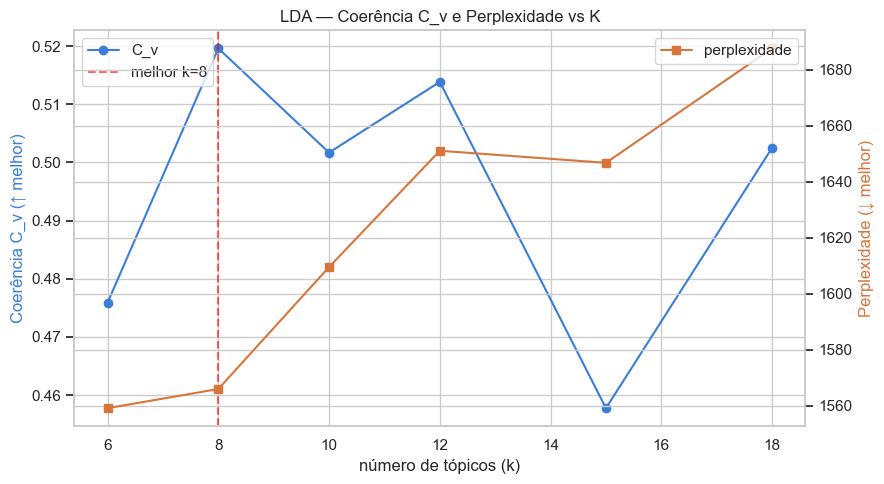


Melhor k por C_v: 8
 k  coerencia_cv  perplexidade
 6      0.475885   1559.151965
 8      0.519615   1565.992675
10      0.501689   1609.536504
12      0.513845   1651.076147
15      0.457761   1646.766100
18      0.502516   1687.654058


In [5]:
if GENSIM_OK:
    if 'tokens_topic' in df.columns and isinstance(df['tokens_topic'].iloc[0], list):
        tokens_corpus = df['tokens_topic'].tolist()
    else:
        tokens_corpus = df['text_for_keywords'].fillna('').str.split().tolist()

    gensim_dict = Dictionary(tokens_corpus)
    gensim_dict.filter_extremes(no_below=5, no_above=0.6)

    bow_vec = CountVectorizer(min_df=5, max_df=0.6, max_features=10_000)
    X_bow   = bow_vec.fit_transform(df['text_for_keywords'].fillna(''))
    vocab_bow = bow_vec.get_feature_names_out()

    K_GRID = [6, 8, 10, 12, 15, 18]
    coh_results = []

    for k in K_GRID:
        lda_k = LatentDirichletAllocation(
            n_components=k, learning_method='online',
            random_state=RANDOM_STATE, max_iter=20, n_jobs=-1
        ).fit(X_bow)

        topics_terms = []
        for comp in lda_k.components_:
            top_idx = comp.argsort()[::-1][:15]
            top_words = [vocab_bow[i] for i in top_idx
                         if vocab_bow[i] in gensim_dict.token2id]
            if len(top_words) >= 2:
                topics_terms.append(top_words)

        cm = CoherenceModel(
            topics=topics_terms, texts=tokens_corpus,
            dictionary=gensim_dict, coherence='c_v'
        )
        score = cm.get_coherence()
        perp  = lda_k.perplexity(X_bow)
        coh_results.append({'k': k, 'coerencia_cv': score, 'perplexidade': perp})
        print(f'k={k:2d} | C_v={score:.4f} | perplexidade={perp:.1f}')

    coh_df = pd.DataFrame(coh_results)
    best_k_cv = int(coh_df.loc[coh_df['coerencia_cv'].idxmax(), 'k'])

    fig, ax1 = plt.subplots(figsize=(9, 5))
    ax1.plot(coh_df['k'], coh_df['coerencia_cv'], marker='o', color='#3b7dd8', label='C_v')
    ax1.set_xlabel('número de tópicos (k)')
    ax1.set_ylabel('Coerência C_v (↑ melhor)', color='#3b7dd8')
    ax1.axvline(best_k_cv, color='red', linestyle='--', alpha=0.6, label=f'melhor k={best_k_cv}')
    ax2 = ax1.twinx()
    ax2.plot(coh_df['k'], coh_df['perplexidade'], marker='s', color='#d8753b', label='perplexidade')
    ax2.set_ylabel('Perplexidade (↓ melhor)', color='#d8753b')
    ax1.legend(loc='upper left'); ax2.legend(loc='upper right')
    plt.title('LDA — Coerência C_v e Perplexidade vs K')
    plt.tight_layout()
    plt.savefig(PASTA_VAL / 'lda_coerencia_cv.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\nMelhor k por C_v: {best_k_cv}')
    coh_df.to_csv(PASTA_VAL / 'lda_coerencia_cv.csv', index=False)
    print(coh_df.to_string(index=False))

## 5. Experimento 2 — LDA × NMF: Tópicos Robustos (Jaccard)

### O que é esta análise?

LDA e NMF partem de premissas matemáticas diferentes:
- **LDA** é probabilístico — cada chunk tem uma distribuição de probabilidade sobre os tópicos
- **NMF** é algébrico — decompõe a matriz TF-IDF em componentes não-negativas

Tópicos que aparecem nos **dois modelos** são mais confiáveis — há duas evidências independentes
de que aquele agrupamento temático existe nos dados. Tópicos que aparecem só num modelo
podem ser artefato da decomposição.

Medimos o **Jaccard** entre os sets de top-N termos de cada tópico LDA e cada tópico NMF.
Um Jaccard ≥ 0.25 indica par robusto.

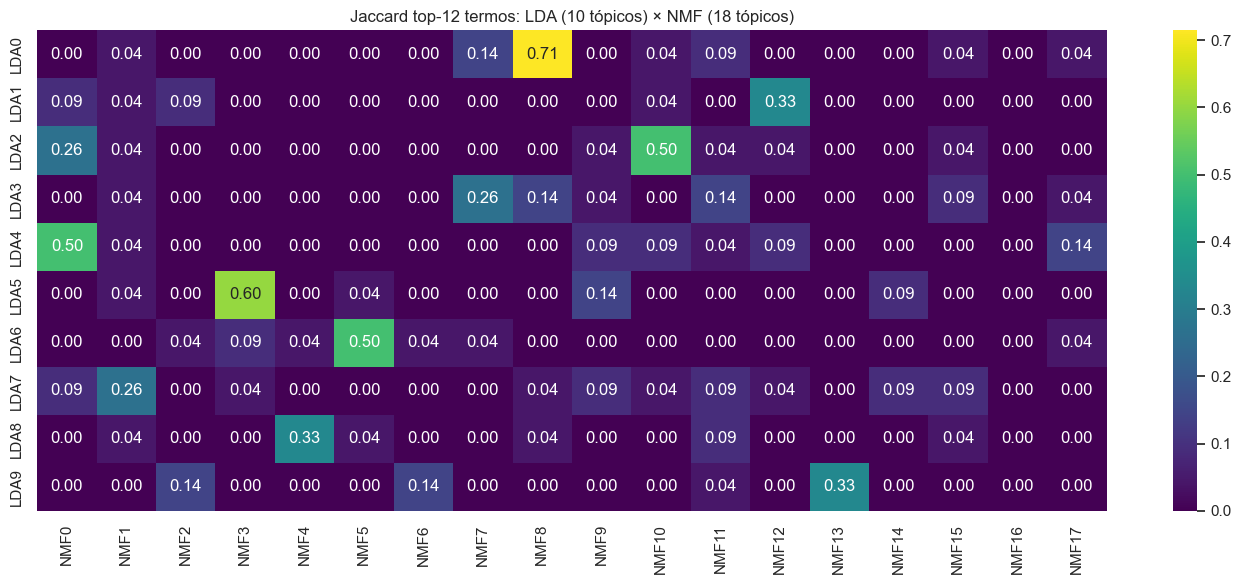

In [6]:
TOP_N       = 12
JAC_LIMIAR  = 0.25

# Extrai set de termos por tópico de cada CSV salvo
def extrair_sets_termos(df_topics, col_terms='top_terms', n=TOP_N):
    sets = []
    for _, row in df_topics.iterrows():
        termos = [t.strip() for t in str(row[col_terms]).split(';')][:n]
        sets.append(set(termos))
    return sets

def jaccard(a, b):
    return len(a & b) / max(len(a | b), 1)

lda_sets = extrair_sets_termos(df_lda_topics)
nmf_sets = extrair_sets_termos(df_nmf_topics)

K_lda = len(lda_sets)
K_nmf = len(nmf_sets)

# Matriz de Jaccard LDA × NMF
J = np.zeros((K_lda, K_nmf))
for i, t_lda in enumerate(lda_sets):
    for j, t_nmf in enumerate(nmf_sets):
        J[i, j] = jaccard(t_lda, t_nmf)

plt.figure(figsize=(14, 6))
sns.heatmap(J, annot=True, fmt='.2f', cmap='viridis',
            xticklabels=[f"NMF{j}" for j in range(K_nmf)],
            yticklabels=[f"LDA{i}" for i in range(K_lda)])
plt.title(f'Jaccard top-{TOP_N} termos: LDA ({K_lda} tópicos) × NMF ({K_nmf} tópicos)')
plt.tight_layout()
plt.savefig(PASTA_VAL / 'jaccard_lda_nmf.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Identifica pares robustos e tópicos frágeis
print(f'Pares LDA → NMF mais próximos (Jaccard ≥ {JAC_LIMIAR}):\n')
robustos, frageis = [], []

for i in range(K_lda):
    j_best = int(np.argmax(J[i]))
    score  = J[i, j_best]
    inter  = sorted(lda_sets[i] & nmf_sets[j_best])
    status = 'ROBUSTO' if score >= JAC_LIMIAR else 'fraco'
    lda_label = df_lda_topics.iloc[i].get('auto_label_short', f'LDA{i}')
    nmf_label = df_nmf_topics.iloc[j_best].get('auto_label_short', f'NMF{j_best}')
    print(f'LDA{i:02d} [{lda_label}]  ↔  NMF{j_best:02d} [{nmf_label}]')
    print(f'  Jaccard={score:.2f} [{status}] | Intersecção: {inter[:6]}')
    print()
    if score >= JAC_LIMIAR:
        robustos.append({'lda_idx': i, 'nmf_idx': j_best, 'jaccard': round(score, 3),
                         'lda_label': lda_label, 'nmf_label': nmf_label,
                         'termos_comuns': ', '.join(inter[:6])})
    else:
        frageis.append(i)

df_robustos = pd.DataFrame(robustos)
print(f'>>> {len(robustos)}/{K_lda} tópicos LDA têm correspondente robusto em NMF')
print(f'>>> Tópicos LDA frágeis (sem par forte): {frageis}')

if len(df_robustos) > 0:
    df_robustos.to_csv(PASTA_VAL / 'topicos_robustos_jaccard.csv', index=False)
    print('\nTabela de pares robustos salva.')

Pares LDA → NMF mais próximos (Jaccard ≥ 0.25):

LDA00 [embalagem / atencao / produto / parece]  ↔  NMF08 [transmite / atencao / parece / embalagem]
  Jaccard=0.71 [ROBUSTO] | Intersecção: ['atencao', 'chama', 'chama atencao', 'embalagem', 'imagem', 'parece']

LDA01 [natura / tempo / pedido / depois]  ↔  NMF12 [pedido / fusao / lider / avon]
  Jaccard=0.33 [ROBUSTO] | Intersecção: ['avon', 'fusao', 'lider', 'natura', 'pedido', 'teve']

LDA02 [loja / boticario / natura / experiencia]  ↔  NMF10 [loja / lojas / boticario / experiencia]
  Jaccard=0.50 [ROBUSTO] | Intersecção: ['boticario', 'experiencia', 'loja', 'lojas', 'natura', 'perfumaria']

LDA03 [produto / embalagem / parece / ver]  ↔  NMF07 [refil / embalagem / parece / formato]
  Jaccard=0.26 [ROBUSTO] | Intersecção: ['diferente', 'embalagem', 'legal', 'parece', 'refil']

LDA04 [natura / perfume / vende / cliente]  ↔  NMF00 [boticario / natura / perfume / vende]
  Jaccard=0.50 [ROBUSTO] | Intersecção: ['boticario', 'clientes', 'mar

## 6. Experimento 3 — Classificação Supervisionada

### O que testamos aqui?

Treinamos classificadores para prever o **projeto** de origem de cada chunk
usando apenas o conteúdo do texto. Se a acurácia for alta, significa que
as entrevistas de cada projeto falam de coisas genuinamente diferentes —
o que valida o trabalho de clusterização e tópicos.

Usamos **StratifiedKFold** (CV k=5) com **f1_macro** como métrica principal,
porque o dataset tem classes desbalanceadas (alguns projetos têm mais entrevistas).

Testamos 4 modelos:
- **Logistic Regression** — baseline linear robusto
- **LinearSVC** — SVM linear, forte para texto
- **MultinomialNB** — Naive Bayes, rápido e simples
- **Random Forest** — não-linear, detecta interações entre termos

In [8]:
LABEL = 'projeto'

# Vetorização TF-IDF sobre text_for_keywords (já pré-processado)
tfidf = TfidfVectorizer(
    ngram_range=(1, 2), min_df=3, max_df=0.7,
    max_features=15_000, sublinear_tf=True
)

mask = df[LABEL].notna() & (df[LABEL].astype(str).str.strip() != '')
X_text = tfidf.fit_transform(df.loc[mask, 'text_for_keywords'].fillna(''))
y      = np.asarray(df.loc[mask, LABEL].astype(str), dtype=str)  # garante numpy puro

# Remove classes com menos de 3 exemplos
vc   = pd.Series(y).value_counts()
keep = vc[vc >= 3].index
sel  = np.isin(y, keep)
X_text, y = X_text[sel], np.asarray(y[sel], dtype=str)

n_min = pd.Series(y).value_counts().min()
k_cv  = int(min(5, n_min))
cv    = StratifiedKFold(n_splits=k_cv, shuffle=True, random_state=RANDOM_STATE)

print(f'Alvo: {LABEL} | n={len(y):,} | classes={len(set(y))} | CV k={k_cv}')
print(pd.Series(y).value_counts().to_string())

Alvo: projeto | n=4,976 | classes=12 | CV k=5
natura_3cs          985
rosacea             539
mercato_brasil      516
compras_digitais    492
3cs_perfumes        485
radiosa             474
gaia_ii             416
anima               406
biome               236
jack_pearson        200
havana_iii          126
bem_maes            101


In [9]:
modelos = {
    'LogReg':        LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
    'LinearSVC':     LinearSVC(class_weight='balanced', random_state=RANDOM_STATE, max_iter=2000),
    'MultinomialNB': MultinomialNB(),
    'RandomForest':  RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                            class_weight='balanced', random_state=RANDOM_STATE),
}

resultados = []
for nome, clf in modelos.items():
    scores = cross_val_score(clf, X_text, y, cv=cv, scoring='f1_macro')
    resultados.append({'modelo': nome, 'f1_macro_media': scores.mean(),
                       'f1_macro_std': scores.std(), 'folds': scores.round(3).tolist()})
    print(f'{nome:15s} f1_macro = {scores.mean():.3f} ± {scores.std():.3f}')

df_resultados = pd.DataFrame(resultados).sort_values('f1_macro_media', ascending=False)
melhor_nome   = df_resultados.iloc[0]['modelo']
melhor_score  = df_resultados.iloc[0]['f1_macro_media']
print(f'\nMelhor modelo: {melhor_nome} ({melhor_score:.3f})')

LogReg          f1_macro = 0.933 ± 0.013
LinearSVC       f1_macro = 0.956 ± 0.011
MultinomialNB   f1_macro = 0.624 ± 0.008
RandomForest    f1_macro = 0.858 ± 0.013

Melhor modelo: LinearSVC (0.956)


Classification report — LinearSVC:
                  precision    recall  f1-score   support

    3cs_perfumes       0.94      0.89      0.91       485
           anima       0.97      0.97      0.97       406
        bem_maes       0.96      0.93      0.94       101
           biome       0.91      0.89      0.90       236
compras_digitais       0.94      0.97      0.95       492
         gaia_ii       0.99      0.97      0.98       416
      havana_iii       0.99      0.98      0.99       126
    jack_pearson       0.99      0.98      0.99       200
  mercato_brasil       0.93      0.95      0.94       516
      natura_3cs       0.92      0.93      0.93       985
         radiosa       0.97      0.98      0.97       474
         rosacea       0.99      0.98      0.98       539

        accuracy                           0.95      4976
       macro avg       0.96      0.95      0.96      4976
    weighted avg       0.95      0.95      0.95      4976



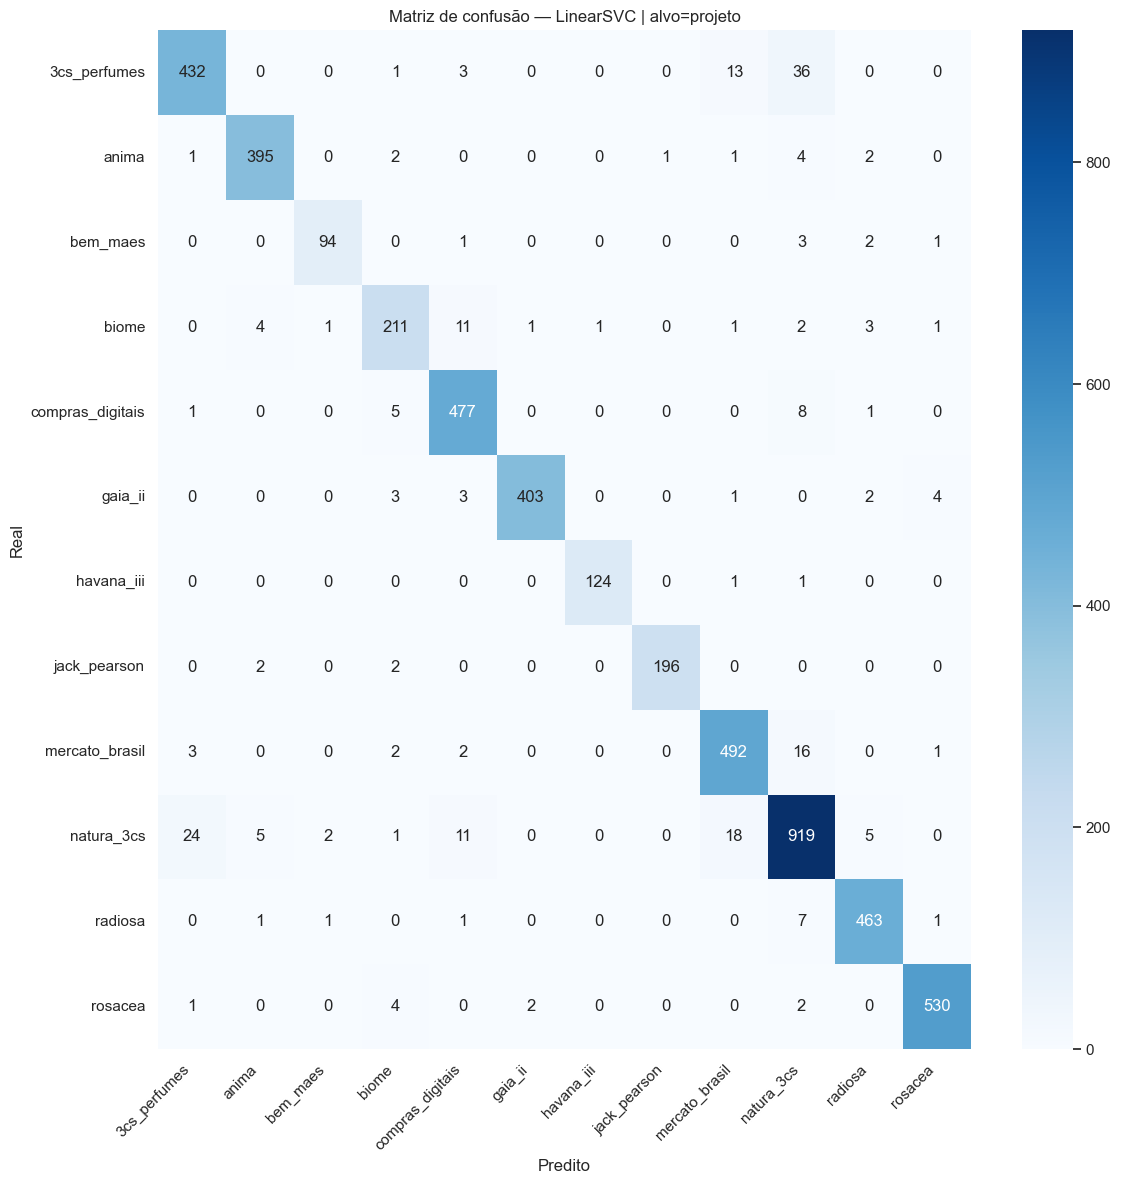

In [10]:
# Relatório detalhado e matriz de confusão do melhor modelo
melhor_clf = modelos[melhor_nome]
y_pred     = cross_val_predict(melhor_clf, X_text, y, cv=cv)

print(f'Classification report — {melhor_nome}:')
print(classification_report(y, y_pred, zero_division=0))

labels = sorted(set(y))
cm     = confusion_matrix(y, y_pred, labels=labels)
plt.figure(figsize=(max(8, len(labels)), max(6, len(labels))))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title(f'Matriz de confusão — {melhor_nome} | alvo={LABEL}')
plt.xlabel('Predito'); plt.ylabel('Real')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(PASTA_VAL / f'confusion_matrix_{LABEL}.png', dpi=150, bbox_inches='tight')
plt.show()

df_resultados.to_csv(PASTA_VAL / f'classificacao_{LABEL}_resultados.csv', index=False)

In [11]:
# Repete para outros alvos relevantes
for label_extra in ['publico', 'marca_foco']:
    if label_extra not in df.columns:
        continue
    mask2 = df[label_extra].notna() & (df[label_extra].astype(str).str.strip() != '')
    if mask2.sum() < 30:
        print(f'{label_extra}: dados insuficientes ({mask2.sum()} amostras)')
        continue
    X2 = tfidf.transform(df.loc[mask2, 'text_for_keywords'].fillna(''))
    y2 = np.asarray(df.loc[mask2, label_extra].astype(str), dtype=str)  # numpy puro
    vc2 = pd.Series(y2).value_counts()
    keep2 = vc2[vc2 >= 3].index
    sel2  = np.isin(y2, keep2)
    X2, y2 = X2[sel2], np.asarray(y2[sel2], dtype=str)
    if len(set(y2)) < 2:
        continue
    k2  = int(min(5, pd.Series(y2).value_counts().min()))
    cv2 = StratifiedKFold(n_splits=k2, shuffle=True, random_state=RANDOM_STATE)
    s = cross_val_score(modelos['LogReg'], X2, y2, cv=cv2, scoring='f1_macro')
    print(f'{label_extra:15s} LogReg f1_macro = {s.mean():.3f} ± {s.std():.3f}  (n={len(y2)}, classes={len(set(y2))})')

publico         LogReg f1_macro = 0.856 ± 0.015  (n=4976, classes=4)
marca_foco      LogReg f1_macro = 0.884 ± 0.005  (n=4976, classes=2)


## 7. Experimento 4 — Termos Mais Discriminativos por Classe (Chi²)

### O que o Chi² mostra?

Para cada projeto (ou público), calculamos o qui-quadrado de cada termo do vocabulário.
Termos com alto Chi² aparecem muito mais naquele projeto do que nos outros —
são as "palavras-chave de identidade" de cada grupo.

Isso serve tanto para validar os clusters quanto para gerar evidência textual
para o relatório final.

In [12]:
termos_vocab = np.array(tfidf.get_feature_names_out())
TOP_CHI2     = 15

linhas_chi2 = []
print(f'Top {TOP_CHI2} termos chi² por {LABEL}:\n')
for cls in sorted(set(y)):
    y_bin       = (y == cls).astype(int)
    chi_scores, _ = chi2(X_text, y_bin)
    top_idx     = chi_scores.argsort()[::-1][:TOP_CHI2]
    top_termos  = termos_vocab[top_idx]
    print(f'[{cls}]: {" | ".join(top_termos)}')
    for rank, (termo, score) in enumerate(zip(top_termos, chi_scores[top_idx]), 1):
        linhas_chi2.append({'classe': cls, 'rank': rank, 'termo': termo, 'chi2': round(float(score), 2)})

pd.DataFrame(linhas_chi2).to_csv(PASTA_VAL / f'chi2_termos_{LABEL}.csv', index=False)
print('\nTabela chi² salva.')

Top 15 termos chi² por projeto:

[3cs_perfumes]: perfumaria | perfumes | boticario | perfume | mari | categoria | olfativo | experimentacao | mario | loja | caminho olfativo | lojas | consumidor | will | repertorio
[anima]: refil | formato | atual | anc | plastico | design | fosco | btc | ceramica | material | prototipo | ecos | transparente | comparar | bico
[bem_maes]: rede apoio | nesse maes | filhos comeca | filho | apoio | mae | stephanie | filhos | mulher mae | cuidar | propaganda maes | natalia | maes | maternidade | frase nesse
[biome]: biome | lixo | barra | lola | rendimento | conscientizacao | rodrigo | marina | shampoo | condicionador | matheus | agroflorestal | concha | zero plastico | xampu
[compras_digitais]: site | interativa | revista | revista interativa | espaco digital | carrinho | frete | espaco | digital | mercado livre | virtual | compro | compra | aplicativo | manda
[gaia_ii]: transmite | tecnologia avancada | avancada | transmitem | marcia | imagens | escolheu 

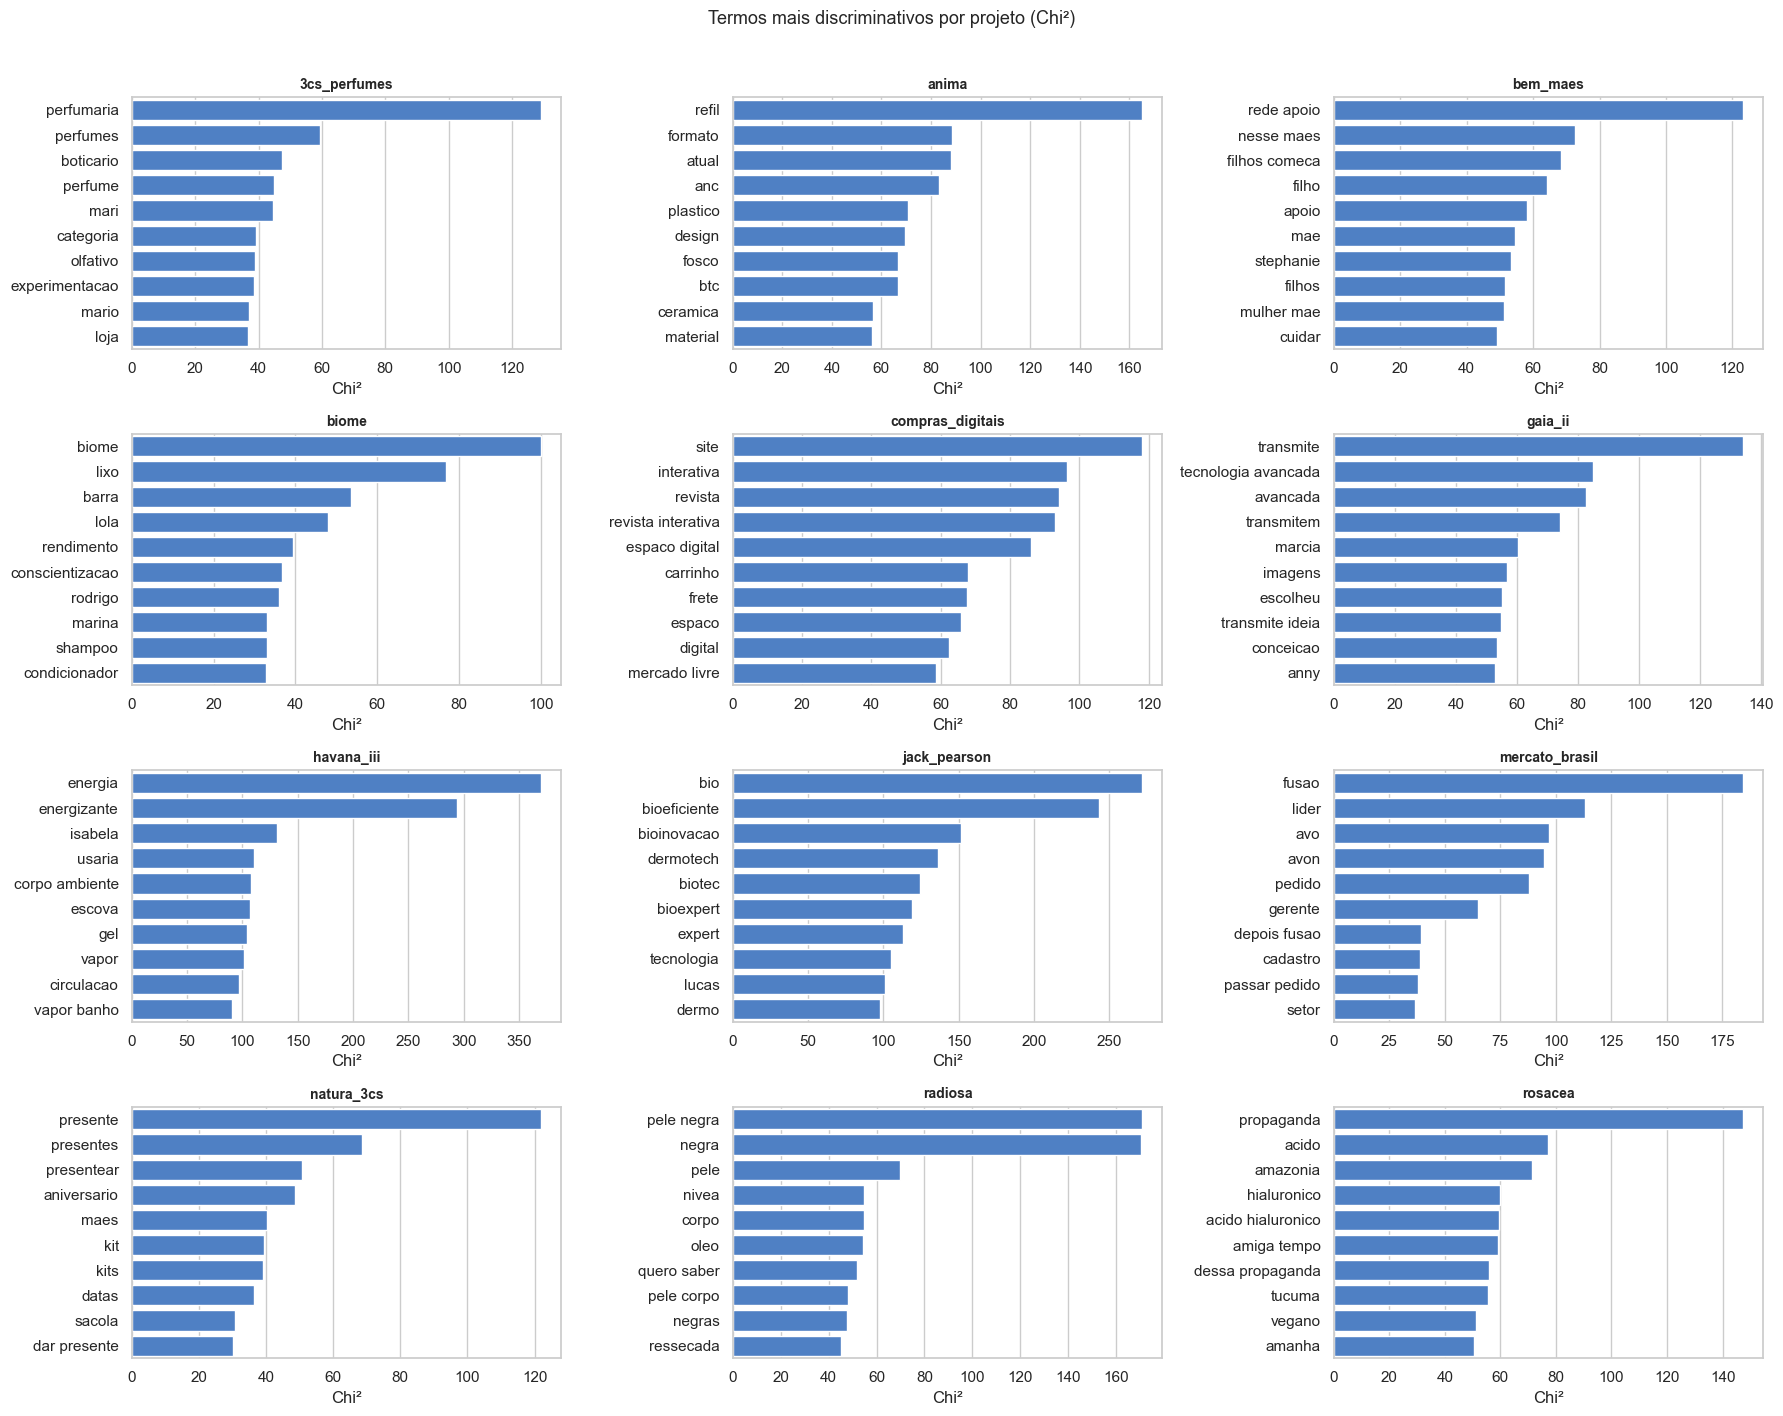

In [13]:
# Visualização — top 10 termos por projeto em grade
classes = sorted(set(y))
n_cols  = 3
n_rows  = (len(classes) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes_flat = axes.ravel() if n_rows > 1 else [axes] if n_cols == 1 else axes.ravel()

for ax, cls in zip(axes_flat, classes):
    y_bin         = (y == cls).astype(int)
    chi_scores, _ = chi2(X_text, y_bin)
    top_idx       = chi_scores.argsort()[::-1][:10]
    top_df        = pd.DataFrame({'termo': termos_vocab[top_idx],
                                   'chi2':  chi_scores[top_idx]})
    sns.barplot(data=top_df, y='termo', x='chi2', ax=ax, color='#3b7dd8')
    ax.set_title(cls, fontsize=10, fontweight='bold')
    ax.set_xlabel('Chi²'); ax.set_ylabel('')

for ax in axes_flat[len(classes):]:
    ax.axis('off')

plt.suptitle(f'Termos mais discriminativos por {LABEL} (Chi²)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PASTA_VAL / f'chi2_grid_{LABEL}.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Análise de Sentimento (Léxico)

### Como funciona?

Usamos um léxico de palavras positivas e negativas em português para calcular
a **valência** de cada chunk:

```
valência = (n_positivas − n_negativas) / total_tokens × 100
```

Depois agregamos por projeto e por cluster para identificar:
- Projetos com discurso mais positivo vs mais crítico
- Clusters que capturam reclamações vs elogios

In [14]:
import unicodedata

def norm(w):
    return ''.join(c for c in unicodedata.normalize('NFD', w.lower())
                   if unicodedata.category(c) != 'Mn')

LEX_POS = {
    'amo', 'adoro', 'gosto', 'gostei', 'otimo', 'bom', 'boa', 'maravilhoso',
    'perfeito', 'incrivel', 'delicioso', 'agradavel', 'satisfeita', 'satisfeito',
    'feliz', 'linda', 'lindo', 'top', 'excelente', 'recomendo', 'amei', 'adorei',
    'encantada', 'encantado', 'qualidade', 'leve', 'suave', 'macio', 'hidrata',
    'pratico', 'pratica', 'facil', 'confianca', 'confia', 'confiavel',
}

LEX_NEG = {
    'odeio', 'ruim', 'pessimo', 'horrivel', 'feio', 'fraco', 'decepcionada',
    'decepcionado', 'irritada', 'irritado', 'chato', 'chata', 'caro', 'fedido',
    'ardido', 'alergia', 'irritou', 'queimou', 'ressecou', 'oleoso', 'oleosa',
    'pegajoso', 'nojento', 'nojo', 'problema', 'reclamacao', 'reclamei',
}

LEX_POS = {norm(w) for w in LEX_POS}
LEX_NEG = {norm(w) for w in LEX_NEG}

def valencia(texto):
    if not isinstance(texto, str) or not texto.strip():
        return 0.0
    toks = texto.split()
    if not toks:
        return 0.0
    pos = sum(1 for t in toks if norm(t) in LEX_POS)
    neg = sum(1 for t in toks if norm(t) in LEX_NEG)
    return (pos - neg) / max(len(toks), 1) * 100

df['valencia'] = df['text_for_keywords'].fillna('').map(valencia)
print(f'Valência calculada para {len(df):,} chunks')
print(f'Média geral: {df["valencia"].mean():.3f} | Mediana: {df["valencia"].median():.3f}')

Valência calculada para 4,976 chunks
Média geral: 0.930 | Mediana: 0.000


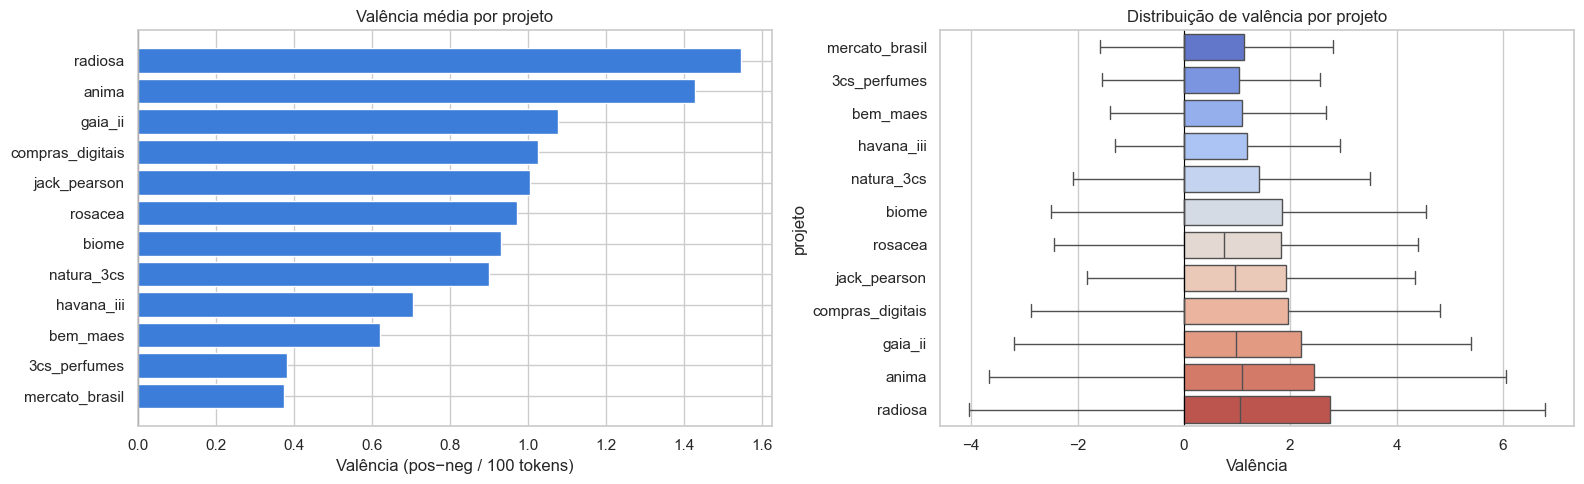

         projeto    media  mediana   n
  mercato_brasil 0.375477 0.000000 516
    3cs_perfumes 0.382712 0.000000 485
        bem_maes 0.619782 0.000000 101
      havana_iii 0.705235 0.000000 126
      natura_3cs 0.899743 0.000000 985
           biome 0.929898 0.000000 236
         rosacea 0.972072 0.763359 539
    jack_pearson 1.005052 0.952381 200
compras_digitais 1.025676 0.000000 492
         gaia_ii 1.076158 0.980392 416
           anima 1.428511 1.098901 406
         radiosa 1.546821 1.063830 474


In [15]:
# Valência por projeto
val_proj = (
    df.groupby('projeto')['valencia']
    .agg(media='mean', mediana='median', n='count')
    .sort_values('media')
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Barplot médias
cores = ['#d94f3d' if v < 0 else '#3b7dd8' for v in val_proj['media']]
axes[0].barh(val_proj['projeto'], val_proj['media'], color=cores)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Valência média por projeto')
axes[0].set_xlabel('Valência (pos−neg / 100 tokens)')

# Boxplot
ordem = val_proj['projeto'].tolist()
sns.boxplot(data=df, y='projeto', x='valencia', order=ordem,
            showfliers=False, ax=axes[1], palette='coolwarm')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Distribuição de valência por projeto')
axes[1].set_xlabel('Valência')

plt.tight_layout()
plt.savefig(PASTA_VAL / 'valencia_por_projeto.png', dpi=150, bbox_inches='tight')
plt.show()

print(val_proj.to_string(index=False))
val_proj.to_csv(PASTA_VAL / 'valencia_por_projeto.csv', index=False)

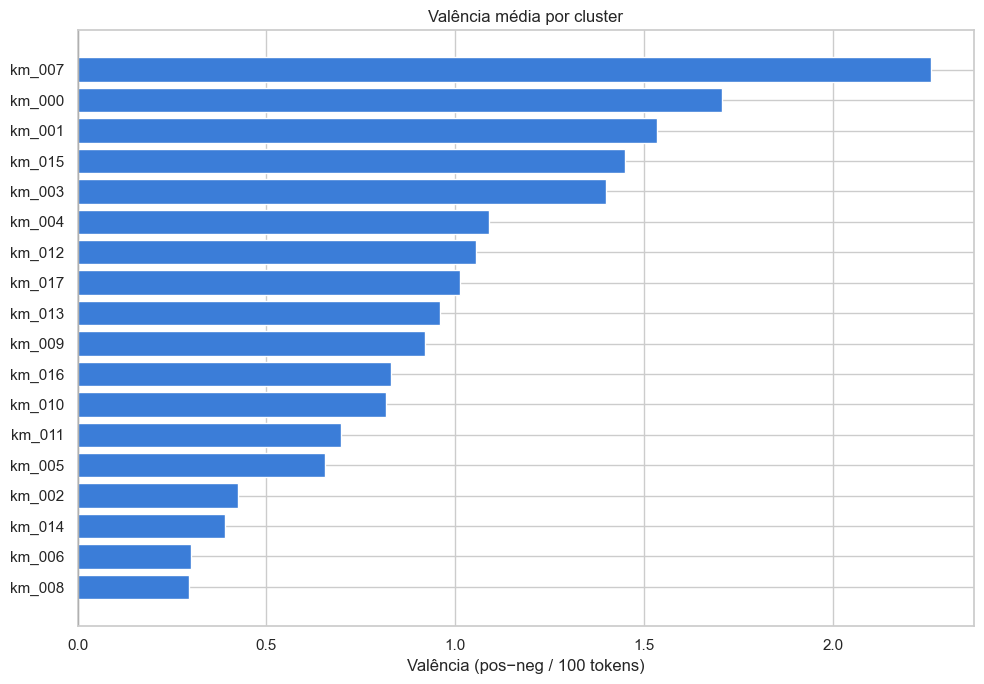

In [16]:
# Valência por cluster (se disponível)
cluster_col = next((c for c in df_clusters.columns
                    if 'cluster' in c.lower() and 'label' in c.lower()), None)
if cluster_col is None:
    cluster_col = next((c for c in df_clusters.columns if 'cluster' in c.lower()), None)

if cluster_col and 'chunk_id' in df_clusters.columns:
    df_val = df[['chunk_id', 'valencia']].merge(
        df_clusters[['chunk_id', cluster_col]], on='chunk_id', how='inner'
    )
    val_cluster = (
        df_val.groupby(cluster_col)['valencia']
        .agg(media='mean', n='count')
        .sort_values('media')
        .reset_index()
    )

    plt.figure(figsize=(10, 7))
    cores_c = ['#d94f3d' if v < 0 else '#3b7dd8' for v in val_cluster['media']]
    plt.barh(val_cluster[cluster_col].astype(str), val_cluster['media'], color=cores_c)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.title('Valência média por cluster')
    plt.xlabel('Valência (pos−neg / 100 tokens)')
    plt.tight_layout()
    plt.savefig(PASTA_VAL / 'valencia_por_cluster.png', dpi=150, bbox_inches='tight')
    plt.show()
    val_cluster.to_csv(PASTA_VAL / 'valencia_por_cluster.csv', index=False)
else:
    print('Coluna de cluster não encontrada em df_clusters — pulando valência por cluster.')

## 9. Resumo dos Resultados

Esta célula imprime um sumário consolidado de todos os experimentos.

In [17]:
print('=' * 65)
print('RESUMO — NOTEBOOK 04: VALIDAÇÃO E EXPERIMENTOS')
print('=' * 65)

if GENSIM_OK and 'coh_df' in dir():
    print(f'\n[C_v Gensim]')
    print(f'  Melhor K por coerência C_v : {best_k_cv}')
    print(f'  C_v máximo                 : {coh_df["coerencia_cv"].max():.4f}')

if 'df_robustos' in dir() and len(df_robustos) > 0:
    print(f'\n[Jaccard LDA × NMF]')
    print(f'  Pares robustos (≥{JAC_LIMIAR}) : {len(df_robustos)}/{K_lda}')
    print(f'  Tópicos LDA frágeis        : {frageis}')

if 'df_resultados' in dir():
    print(f'\n[Classificação supervisionada — alvo: {LABEL}]')
    for _, row in df_resultados.iterrows():
        print(f'  {row["modelo"]:15s} f1_macro = {row["f1_macro_media"]:.3f} ± {row["f1_macro_std"]:.3f}')

if 'val_proj' in dir():
    mais_pos  = val_proj.iloc[-1]
    mais_neg  = val_proj.iloc[0]
    print(f'\n[Sentimento]')
    print(f'  Projeto mais positivo : {mais_pos["projeto"]} ({mais_pos["media"]:+.3f})')
    print(f'  Projeto mais negativo : {mais_neg["projeto"]} ({mais_neg["media"]:+.3f})')

print(f'\n[Outputs salvos em]')
print(f'  {PASTA_VAL}')
for f in sorted(PASTA_VAL.glob('*')):
    print(f'  └─ {f.name}')

RESUMO — NOTEBOOK 04: VALIDAÇÃO E EXPERIMENTOS

[C_v Gensim]
  Melhor K por coerência C_v : 8
  C_v máximo                 : 0.5196

[Jaccard LDA × NMF]
  Pares robustos (≥0.25) : 10/10
  Tópicos LDA frágeis        : []

[Classificação supervisionada — alvo: projeto]
  LinearSVC       f1_macro = 0.956 ± 0.011
  LogReg          f1_macro = 0.933 ± 0.013
  RandomForest    f1_macro = 0.858 ± 0.013
  MultinomialNB   f1_macro = 0.624 ± 0.008

[Sentimento]
  Projeto mais positivo : radiosa (+1.547)
  Projeto mais negativo : mercato_brasil (+0.375)

[Outputs salvos em]
  /Users/I759133/Library/CloudStorage/OneDrive-SAPSE/Documentos Juliane/IBMEC/SEXTO SEMESTRE/PROJETO/kyrapesquisa/Kyra Atual/outputs/validacao
  └─ chi2_grid_projeto.png
  └─ chi2_termos_projeto.csv
  └─ classificacao_projeto_resultados.csv
  └─ confusion_matrix_projeto.png
  └─ jaccard_lda_nmf.png
  └─ lda_coerencia_cv.csv
  └─ lda_coerencia_cv.png
  └─ topicos_robustos_jaccard.csv
  └─ valencia_por_cluster.csv
  └─ valencia_po

## 10. Complementos para XAI e Diagnóstico

Esta seção adiciona os blocos exigidos pelo checklist de XAI (Aula 10):

| Bloco | O que valida |
|---|---|
| **10.1 Baseline Honesto** | O modelo supera o trivial `DummyClassifier`? Comparação com accuracy e F1-macro |
| **10.2 Leakage Semântico** | O F1=0.956 vem de aprendizado real ou de termos que "entregam" o projeto? |
| **10.3 Confusão Dissecada** | Quais pares de projetos são mais confundidos e em que quantidade? |
| **10.4 Exemplos Reais de Erros** | Trechos originais com erro + causa provável |

**Variáveis reutilizadas das seções anteriores:** `X_text`, `y`, `y_pred`, `cv`, `tfidf`,
`melhor_score`, `labels`, `cm`, `_root`, `RANDOM_STATE`.

**Outputs:** `outputs/tabelas/`

### 10.1 Baseline Honesto

Adiciona `DummyClassifier(strategy='most_frequent')` à comparação. Um modelo útil deve
superar com clareza este baseline trivial — caso contrário, não justifica sua complexidade.

A tabela reporta **Accuracy** e **F1-macro** (médias de CV k=5). F1-macro é a métrica
principal por causa do desbalanceamento entre projetos (de 101 a 985 chunks).

In [ ]:
from sklearn.dummy import DummyClassifier

PASTA_TABELAS = _root / 'outputs' / 'tabelas'
PASTA_TABELAS.mkdir(parents=True, exist_ok=True)

# Modelos a comparar — inclui Dummy e reutiliza os já definidos na seção 6
modelos_cmp = {
    'DummyClassifier': DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE),
    'MultinomialNB':   MultinomialNB(),
    'LogReg':          LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
    'RandomForest':    RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                              class_weight='balanced', random_state=RANDOM_STATE),
    'LinearSVC':       LinearSVC(class_weight='balanced', random_state=RANDOM_STATE, max_iter=2000),
}

obs_map = {
    'DummyClassifier': 'Baseline trivial — sempre prevê a classe mais frequente',
    'MultinomialNB':   'Naive Bayes — baseline probabilístico simples',
    'LogReg':          'Regressão Logística — linear com regularização',
    'RandomForest':    'Random Forest — não-linear, detecta interações entre termos',
    'LinearSVC':       'SVM linear — melhor modelo (ver seção 6)',
}

linhas_cmp = []
print(f'{"Modelo":<18}  {"Accuracy":>9}  {"F1-macro":>9}')
print('-' * 44)

for nome, clf in modelos_cmp.items():
    acc = cross_val_score(clf, X_text, y, cv=cv, scoring='accuracy')
    f1  = cross_val_score(clf, X_text, y, cv=cv, scoring='f1_macro')
    linhas_cmp.append({
        'modelo':    nome,
        'accuracy':  round(float(acc.mean()), 4),
        'f1_macro':  round(float(f1.mean()), 4),
        'observacao': obs_map[nome],
    })
    print(f'{nome:<18}  {acc.mean():>9.3f}  {f1.mean():>9.3f}')

df_cmp = (
    pd.DataFrame(linhas_cmp)
    .sort_values('f1_macro', ascending=False)
    .reset_index(drop=True)
)
df_cmp.to_csv(PASTA_TABELAS / 'comparacao_baseline_modelos.csv', index=False)
print(f'\nArquivo salvo: {PASTA_TABELAS / "comparacao_baseline_modelos.csv"}')
display(df_cmp)


### 10.2 Diagnóstico de Possível Leakage Semântico

O LinearSVC atingiu F1-macro = 0.956 — valor alto que merece investigação.
Uma causa possível: os textos contêm nomes de marcas ou projetos que "entregam" o rótulo
sem aprendizado semântico real (ex: a palavra "radiosa" num chunk identifica trivialmente
o projeto `radiosa`).

Estratégia: removemos uma blocklist de termos suspeitos, revectorizamos e retreinamos
o melhor modelo. Se o F1 cair mais de 5 pp, há evidência de leakage.

In [ ]:
termos_suspeitos = [
    'natura', 'avon', 'boticario', 'boticário',
    'radiosa', 'kyra'
]

pat_sus = re.compile(
    r'\b(' + '|'.join(re.escape(t) for t in termos_suspeitos) + r')\b',
    re.IGNORECASE
)

# Diagnostica presença dos termos no corpus
mask_sus = df['text_for_keywords'].fillna('').str.contains(pat_sus, regex=True)
n_afetados = int(mask_sus.sum())
print(f'Chunks com ao menos um termo suspeito: {n_afetados:,} de {len(df):,} ({n_afetados / len(df) * 100:.1f}%)')

# Remove termos suspeitos e revectoriza com mesma configuração do TF-IDF original
texto_filtrado = df['text_for_keywords'].fillna('').str.replace(pat_sus, '', regex=True)

mask_lk = df['projeto'].notna() & (df['projeto'].astype(str).str.strip() != '')
tfidf_lk = TfidfVectorizer(
    ngram_range=(1, 2), min_df=3, max_df=0.7,
    max_features=15_000, sublinear_tf=True
)
X_lk = tfidf_lk.fit_transform(texto_filtrado[mask_lk])
y_lk = np.asarray(df.loc[mask_lk, 'projeto'].astype(str), dtype=str)

vc_lk  = pd.Series(y_lk).value_counts()
sel_lk = np.isin(y_lk, vc_lk[vc_lk >= 3].index)
X_lk, y_lk = X_lk[sel_lk], y_lk[sel_lk]

svc_lk    = LinearSVC(class_weight='balanced', random_state=RANDOM_STATE, max_iter=2000)
f1_depois = cross_val_score(svc_lk, X_lk, y_lk, cv=cv, scoring='f1_macro').mean()

f1_antes = melhor_score
delta    = f1_depois - f1_antes

if abs(delta) > 0.05:
    conclusao = 'Queda significativa (>5 pp): termos suspeitos inflavam o F1 — leakage confirmado.'
elif delta < -0.01:
    conclusao = 'Queda pequena (<5 pp): termos suspeitos contribuem mas não explicam o F1 alto sozinhos.'
else:
    conclusao = 'Sem queda relevante: F1 alto é sustentado pelo conteúdo semântico real.'

print(f'\nLinearSVC f1_macro COM termos suspeitos : {f1_antes:.3f}')
print(f'LinearSVC f1_macro SEM termos suspeitos : {f1_depois:.3f}')
print(f'Delta                                   : {delta:+.3f}')
print(f'\nConclusão: {conclusao}')

df_leakage = pd.DataFrame([{
    'modelo':                  'LinearSVC',
    'f1_macro_com_suspeitos':  round(f1_antes, 4),
    'f1_macro_sem_suspeitos':  round(f1_depois, 4),
    'delta':                   round(delta, 4),
    'termos_testados':         ', '.join(termos_suspeitos),
    'chunks_com_termos':       n_afetados,
    'pct_chunks_afetados':     round(n_afetados / len(df) * 100, 1),
    'conclusao':               conclusao,
}])
df_leakage.to_csv(PASTA_TABELAS / 'diagnostico_leakage_semantico.csv', index=False)
print(f'\nArquivo salvo: {PASTA_TABELAS / "diagnostico_leakage_semantico.csv"}')


### 10.3 Matriz de Confusão Dissecada

Ignorando a diagonal principal (acertos), extraímos os maiores erros entre pares de projetos.
Pares com muitos erros tendem a compartilhar vocabulário ou contexto temático similar,
o que é uma informação de diagnóstico mais útil do que o F1 agregado.

In [ ]:
# Usa cm e labels já definidos na seção 6
linhas_cf = []
for i, real in enumerate(labels):
    for j, pred_cls in enumerate(labels):
        if i != j and cm[i, j] > 0:
            linhas_cf.append({
                'projeto_real':           real,
                'projeto_previsto':       pred_cls,
                'qtd_erros':              int(cm[i, j]),
                'possivel_interpretacao': 'a verificar — vocabulário temático compartilhado',
            })

df_confusoes = (
    pd.DataFrame(linhas_cf)
    .sort_values('qtd_erros', ascending=False)
    .reset_index(drop=True)
)

total_erros = df_confusoes['qtd_erros'].sum()
print(f'Pares de projetos com erro (off-diagonal) : {len(df_confusoes)}')
print(f'Total de predições erradas                : {total_erros}')
print(f'(de {len(y):,} chunks — taxa de erro = {total_erros / len(y) * 100:.1f}%)\n')
print(df_confusoes.head(15).to_string(index=False))

df_confusoes.to_csv(PASTA_TABELAS / 'confusoes_classificacao.csv', index=False)
print(f'\nArquivo salvo: {PASTA_TABELAS / "confusoes_classificacao.csv"}')


### 10.4 Exemplos Reais de Erros

Extrai até 20 chunks em que o modelo errou (`y_true ≠ y_pred`), com o trecho original
e uma causa provável baseada em similaridade temática entre projetos.

Esses exemplos fundamentam a análise qualitativa de erro exigida na apresentação final
("Análise sistemática de erros — exemplos reais de acertos e erros").

In [ ]:
# Reconstrói df alinhado com y e y_pred (mesma máscara da seção 6)
mask_al = df['projeto'].notna() & (df['projeto'].astype(str).str.strip() != '')
df_al   = df[mask_al].reset_index(drop=True)
y_al    = np.asarray(df_al['projeto'].astype(str), dtype=str)

vc_al  = pd.Series(y_al).value_counts()
sel_al = np.isin(y_al, vc_al[vc_al >= 3].index)
df_al  = df_al[sel_al].reset_index(drop=True)

assert len(df_al) == len(y), (
    f"Desalinhamento: df_al={len(df_al)} linhas vs y={len(y)} — "
    "verifique se o notebook foi rodado em sequência."
)

df_al = df_al.copy()
df_al['projeto_real']     = y
df_al['projeto_previsto'] = y_pred

erros_al = df_al[df_al['projeto_real'] != df_al['projeto_previsto']].copy()
print(f'Chunks errados: {len(erros_al):,} de {len(df_al):,} ({len(erros_al)/len(df_al)*100:.1f}%)')

col_texto = 'text_for_embedding' if 'text_for_embedding' in df_al.columns else 'text_for_keywords'

# Heurística de causa provável agrupando projetos com vocabulário afim
GRUPOS_SEMANTICOS = [
    {'natura_3cs', '3cs_perfumes'},
    {'radiosa', 'biome', 'rosacea', 'anima', 'gaia_ii'},
    {'mercato_brasil', 'compras_digitais'},
    {'bem_maes', 'jack_pearson'},
    {'havana_iii', 'gaia_ii'},
]

def causa_provavel(real, pred):
    for grupo in GRUPOS_SEMANTICOS:
        if real in grupo and pred in grupo:
            return 'Projetos com vocabulário temático similar'
    return 'Termos genéricos ou sobreposição de contexto'

amostra_erros = erros_al.sample(n=min(20, len(erros_al)), random_state=RANDOM_STATE)

col_id = 'doc_id' if 'doc_id' in amostra_erros.columns else 'chunk_id'
df_erros_export = pd.DataFrame({
    'doc_id':           amostra_erros[col_id].values,
    'chunk_id':         amostra_erros['chunk_id'].values,
    'projeto_real':     amostra_erros['projeto_real'].values,
    'projeto_previsto': amostra_erros['projeto_previsto'].values,
    'trecho':           amostra_erros[col_texto].fillna('').str[:300].values,
    'possivel_causa':   [
        causa_provavel(r, p)
        for r, p in zip(amostra_erros['projeto_real'], amostra_erros['projeto_previsto'])
    ],
})

display(df_erros_export[['projeto_real', 'projeto_previsto', 'possivel_causa', 'trecho']])

df_erros_export.to_csv(PASTA_TABELAS / 'exemplos_erros_classificacao.csv', index=False)
print(f'\nArquivo salvo: {PASTA_TABELAS / "exemplos_erros_classificacao.csv"}')
